
# Triadic Cell Notebook v17
## Coupled fields runtime: heat, ambiguity, trust, scar

v16 showed a real split:

- trust improves passive closure
- ledger improves ambiguity separation
- raw bank/latent still carries the strongest direct retrieval
- one scalar `search_pressure` is too crude

So v17 stops summing the runtime into one number.

Instead, it models four interacting fields directly:

1. **heat**
   - branch support / route activation

2. **ambiguity**
   - competition between the top branches

3. **trust**
   - commitment readiness / acceptance gate

4. **scar**
   - residue of bad writes, rewrite spill, unresolved contradiction

This notebook treats the new AI as a **coupled-field runtime** rather than a single loss.



## Runtime picture

The fields interact as follows:

$$
H_{t+1} \leftarrow f_H(\text{cue fit}, \text{bank geometry}, T_t, S_t)
$$

$$
A_{t+1} \leftarrow f_A(\text{top-2 competition}, H_t, S_t)
$$

$$
T_{t+1} \leftarrow f_T(H_t, A_t, S_t)
$$

$$
S_{t+1} \leftarrow f_S(\text{rewrite spill}, \text{contradiction}, T_t)
$$

Where:
- higher heat helps commitment
- higher ambiguity suppresses commitment
- higher scar suppresses trust and weakens future writes
- trust modulates whether the system commits or keeps the branch provisional

Outcome metrics such as omega and STI are witnesses, not objectives.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)

    def copy(self):
        return AddressedTriadicState(
            coherence=float(self.coherence),
            latent=self.latent.copy(),
            readout=self.readout.copy(),
        )


@dataclass
class FieldState:
    heat: float = 0.50
    ambiguity: float = 0.50
    trust: float = 0.50
    scar: float = 0.10
    omega_history: list = None

    def __post_init__(self):
        if self.omega_history is None:
            self.omega_history = []

    def copy(self):
        return FieldState(
            heat=float(self.heat),
            ambiguity=float(self.ambiguity),
            trust=float(self.trust),
            scar=float(self.scar),
            omega_history=list(self.omega_history),
        )


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)
        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 1):
        before = self.slots.copy()
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(self.slots[i] + strength * masked[i] * value, 0.0, 1.0)

        delta = self.slots - before
        return masked.copy(), delta

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def copy(self):
        return copy.deepcopy(self)


In [4]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def top2_margin(scores: np.ndarray):
    order = np.argsort(scores)[::-1]
    top1 = float(scores[order[0]])
    top2 = float(scores[order[1]]) if len(order) > 1 else 0.0
    return int(order[0]), top1, top1 - top2


In [5]:

class TriadicCellV17:
    def __init__(self, B: float = 1.0, T: float = 1.0, R: float = 1.0):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        fields: FieldState,
        target_slot: int | None = None,
        templates: np.ndarray | None = None,
        base_template_pull: float = 0.35,
        novelty_threshold: float = 0.10,
    ):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)
        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        gate = max(0.0, 0.55 * fields.heat + 0.35 * fields.trust - 0.30 * fields.ambiguity - 0.25 * fields.scar)
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        base_write_strength = float(support * readout.mean())
        write_strength = base_write_strength * novelty * gate

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        write_value = latent.copy()
        if target_slot is not None and templates is not None:
            local_pull = np.clip(
                base_template_pull + 0.30 * fields.scar - 0.15 * fields.ambiguity + 0.10 * fields.trust,
                0.10,
                0.85,
            )
            write_value = np.clip((1.0 - local_pull) * latent + local_pull * templates[target_slot], 0.0, 1.0)

        _, delta = bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, delta



## Patterns and cues


In [6]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    return np.clip(cue, 0.0, 1.0)


In [7]:

def apply_persistence_mode(mode: str, state: AddressedTriadicState, bank: KeyedMemoryBank, fields: FieldState):
    if mode == "bank + latent":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        return s, bank.copy(), FieldState()

    if mode == "bank + latent + trust":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        f = FieldState(trust=float(fields.trust))
        return s, bank.copy(), f

    if mode == "bank + latent + coupled":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        return s, bank.copy(), fields.copy()

    if mode == "full + coupled":
        return state.copy(), bank.copy(), fields.copy()

    raise ValueError(f"Unknown mode: {mode}")



## Coupled-field episode

We update the fields from measured branch behavior:

- heat rises with cue-template agreement and branch margin
- ambiguity rises when top-2 competition is tight
- trust rises when heat wins over ambiguity and scar
- scar rises with contradiction and rewrite spill, then decays slowly


In [8]:

def run_episode(
    model: TriadicCellV17,
    state: AddressedTriadicState,
    bank: KeyedMemoryBank,
    fields: FieldState,
    zero_floor: float = 0.05,
):
    rewrite_spill_terms = []

    for slot_idx, p in enumerate(patterns):
        for _ in range(10):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state, delta = model.step(
                state,
                drive,
                bank,
                fields,
                target_slot=slot_idx,
                templates=patterns,
                base_template_pull=0.35,
                novelty_threshold=0.10,
            )

            slot_delta = np.mean(np.abs(delta), axis=1)
            target_change = slot_delta[slot_idx]
            collateral = np.mean(np.delete(slot_delta, slot_idx))
            rewrite_spill = collateral / (target_change + 1e-8)
            rewrite_spill_terms.append(rewrite_spill)

    rows = []
    bank_templates = bank.slots.copy()

    for idx, p in enumerate(patterns):
        for _ in range(16):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            _, recalled = model.probe(cue, bank)

            sims = np.array([cosine_similarity(recalled, t) for t in bank_templates], dtype=float)
            pred_bank, top1, margin = top2_margin(sims)

            omega = 1.0 - cosine_similarity(recalled, p)
            ambiguity_obs = 1.0 - np.clip(margin, 0.0, 1.0)
            rewrite_error = float(np.mean(rewrite_spill_terms)) if rewrite_spill_terms else 0.0

            heat_obs = np.clip(0.55 * top1 + 0.25 * margin + 0.20 * (1.0 - omega), 0.0, 1.0)
            fields.heat = 0.85 * fields.heat + 0.15 * heat_obs

            fields.ambiguity = 0.80 * fields.ambiguity + 0.20 * ambiguity_obs

            trust_drive = np.clip(fields.heat - 0.60 * fields.ambiguity - 0.50 * fields.scar, -1.0, 1.0)
            fields.trust = np.clip(0.88 * fields.trust + 0.12 * (0.5 + 0.5 * trust_drive), 0.0, 1.0)

            scar_drive = np.clip(0.60 * omega + 0.40 * rewrite_error, 0.0, 1.0)
            fields.scar = np.clip(0.92 * fields.scar + 0.08 * scar_drive, 0.0, 1.0)

            accepted = (fields.trust > 0.56) and (fields.ambiguity < 0.68)

            rows.append({
                "target_slot": idx,
                "pred_bank": pred_bank,
                "omega": omega,
                "margin": margin,
                "accepted": accepted,
                "zero_hit": omega < zero_floor,
                "heat": float(fields.heat),
                "ambiguity": float(fields.ambiguity),
                "trust": float(fields.trust),
                "scar": float(fields.scar),
                "rewrite_error": rewrite_error,
            })

            fields.omega_history.append(omega)

    probe_df = pd.DataFrame(rows)
    return state, bank, fields, probe_df


In [9]:

def summarize_episode(probe_df: pd.DataFrame, bank: KeyedMemoryBank, fields: FieldState):
    bank_acc = float((probe_df["pred_bank"] == probe_df["target_slot"]).mean())

    accepted = probe_df[probe_df["accepted"]].copy()
    coverage = len(accepted) / len(probe_df)
    accepted_acc = float((accepted["pred_bank"] == accepted["target_slot"]).mean()) if len(accepted) else np.nan

    mean_omega = float(probe_df["omega"].mean())
    sti = 1.0 - mean_omega

    return {
        "bank_accuracy": bank_acc,
        "coverage": coverage,
        "accepted_accuracy": accepted_acc,
        "mean_omega": mean_omega,
        "sti": sti,
        "mean_margin": float(probe_df["margin"].mean()),
        "zero_hit_rate": float(probe_df["zero_hit"].mean()),
        "slot_divergence": float(np.std(bank.slot_energy())),
        "heat_state": float(fields.heat),
        "ambiguity_state": float(fields.ambiguity),
        "trust_state": float(fields.trust),
        "scar_state": float(fields.scar),
        "mean_rewrite_error": float(probe_df["rewrite_error"].mean()),
    }



## Run the coupled-field experiment


In [10]:

def run_coupled_experiment(mode: str, episodes: int = 24):
    model = TriadicCellV17()
    state = AddressedTriadicState()
    bank = KeyedMemoryBank(width=4, leak=0.015)
    fields = FieldState()

    rows = []
    for ep in range(episodes):
        state, bank, fields, probe_df = run_episode(model, state, bank, fields)
        summary = summarize_episode(probe_df, bank, fields)
        summary["episode"] = ep
        summary["mode"] = mode
        rows.append(summary)

        state, bank, fields = apply_persistence_mode(mode, state, bank, fields)

    return pd.DataFrame(rows)

modes = [
    "bank + latent",
    "bank + latent + trust",
    "bank + latent + coupled",
    "full + coupled",
]

results = pd.concat([run_coupled_experiment(mode) for mode in modes], ignore_index=True)
results.head()


,bank_accuracy,coverage,accepted_accuracy,mean_omega,sti,mean_margin,zero_hit_rate,slot_divergence,heat_state,ambiguity_state,trust_state,scar_state,mean_rewrite_error,episode,mode
0,0.640625,0.312500,0.750000,0.296067,0.703933,0.325014,0.0,0.010227,0.814279,0.568358,0.652456,0.227711,0.200297,0,bank + latent
1,0.578125,0.828125,0.584906,0.337557,0.662443,0.372891,0.0,0.013881,0.786005,0.586117,0.593251,0.394280,0.504743,1,bank + latent
2,0.531250,0.515625,0.666667,0.358081,0.641919,0.361148,0.0,0.015769,0.755483,0.689461,0.598928,0.429141,0.646693,2,bank + latent
3,0.687500,0.859375,0.709091,0.282203,0.717797,0.381665,0.0,0.017552,0.771676,0.614997,0.580773,0.521467,0.865203,3,bank + latent
4,0.625000,0.625000,0.650000,0.329822,0.670178,0.390397,0.0,0.018780,0.791420,0.578842,0.559440,0.563988,0.896994,4,bank + latent



## Episode trajectories


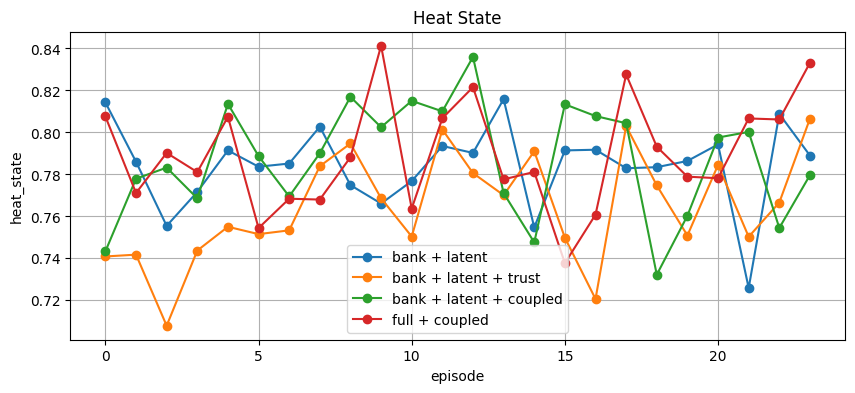

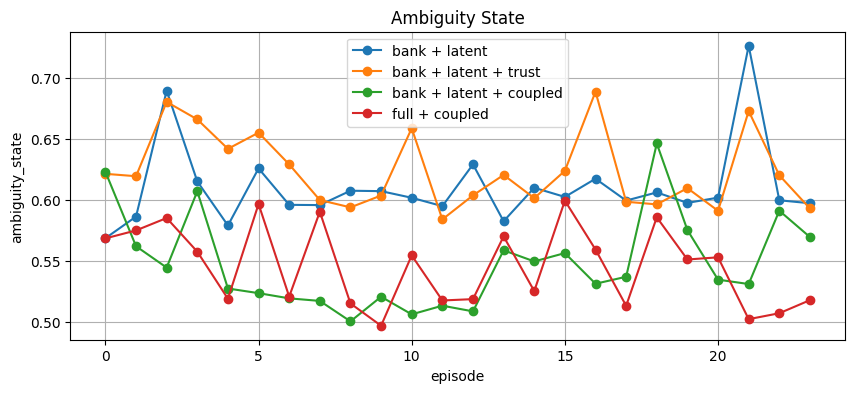

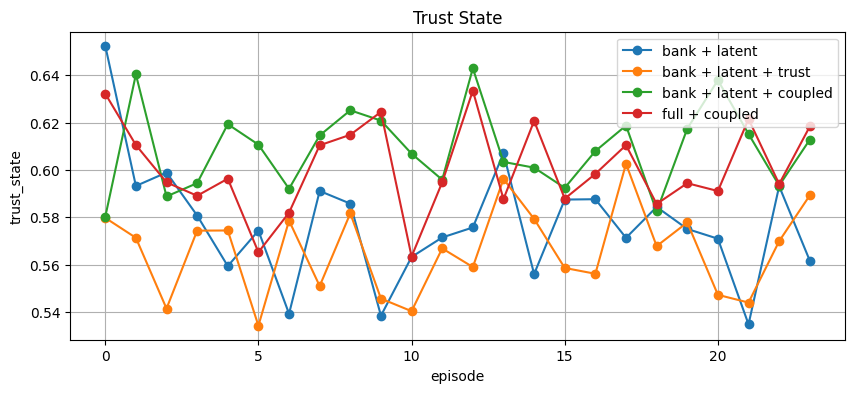

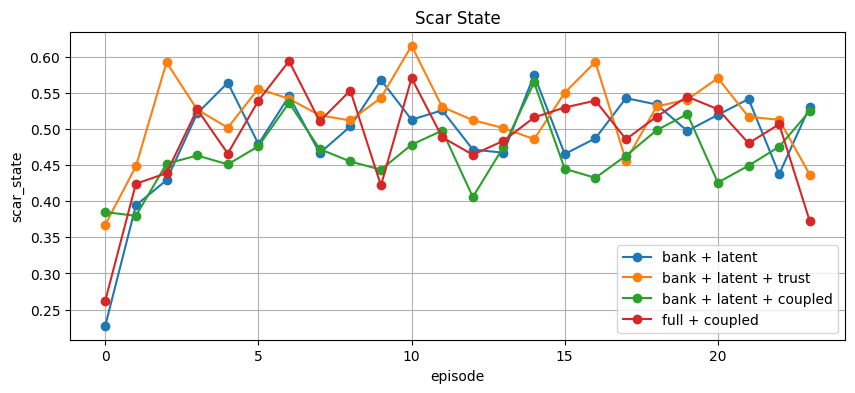

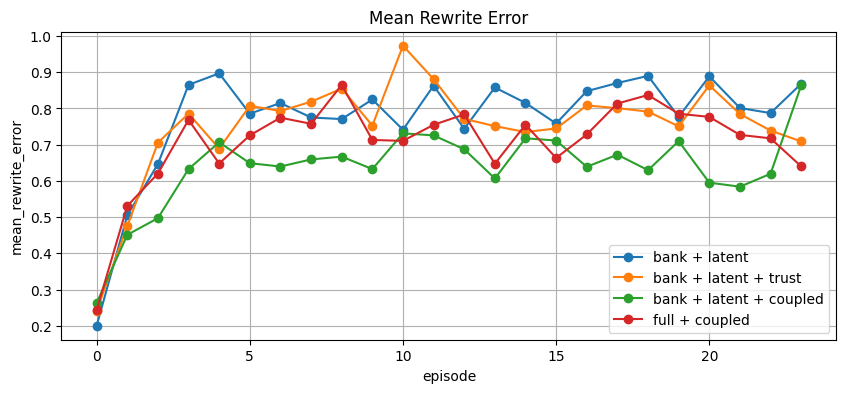

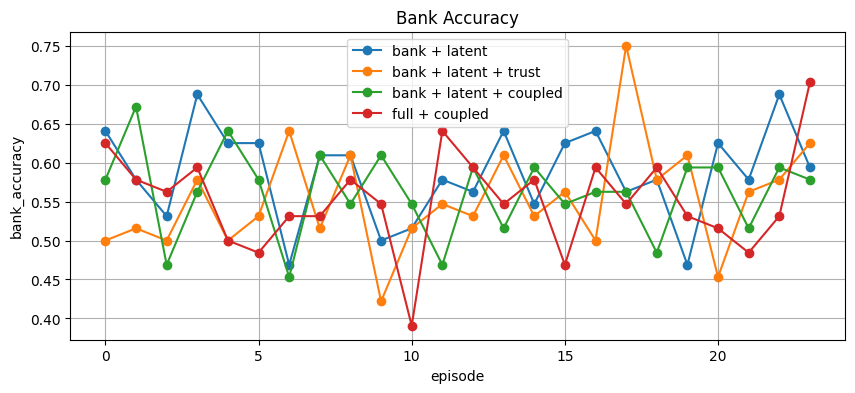

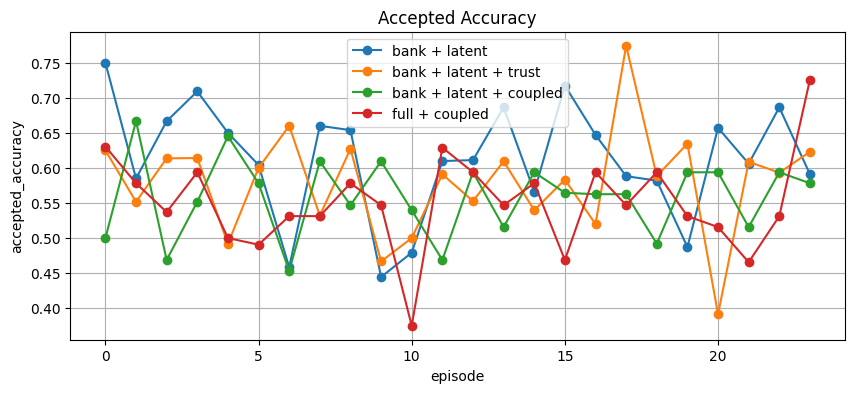

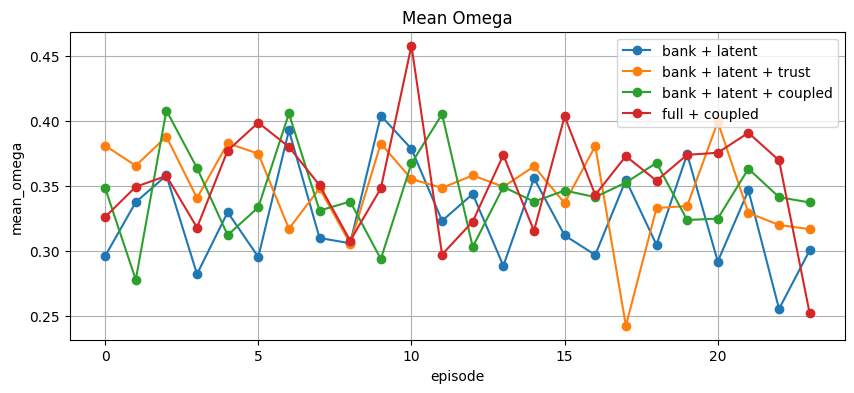

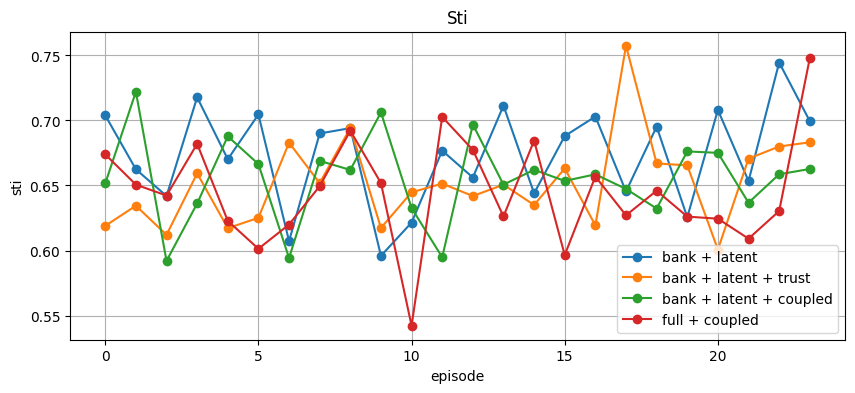

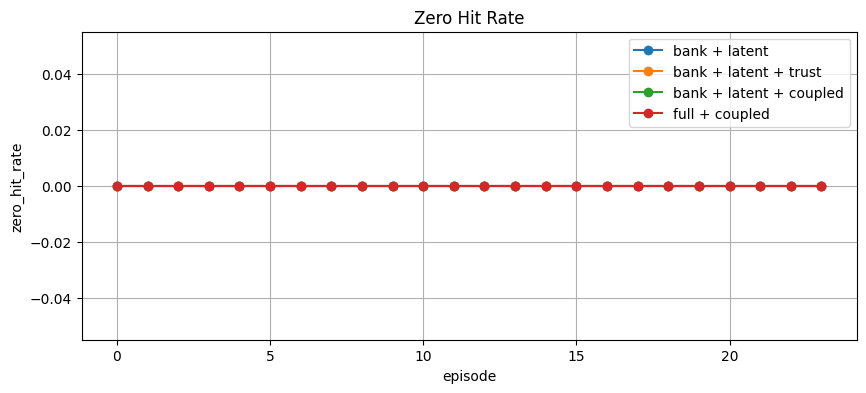

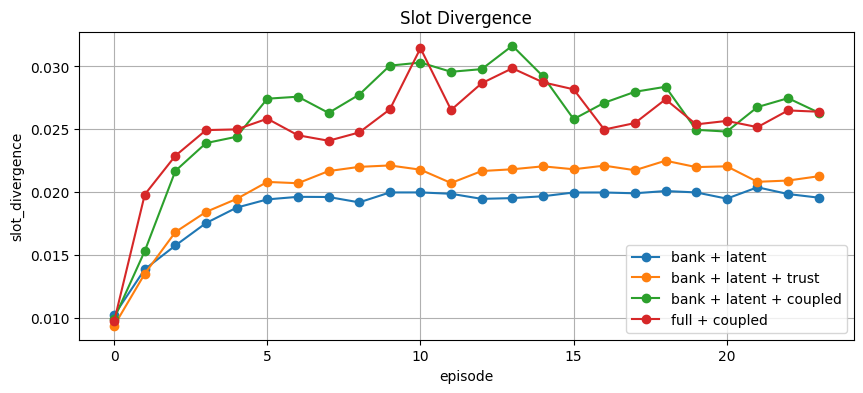

In [11]:

metrics = [
    "heat_state",
    "ambiguity_state",
    "trust_state",
    "scar_state",
    "mean_rewrite_error",
    "bank_accuracy",
    "accepted_accuracy",
    "mean_omega",
    "sti",
    "zero_hit_rate",
    "slot_divergence",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    for mode in modes:
        df = results[results["mode"] == mode]
        plt.plot(df["episode"], df[metric], marker="o", label=mode)
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("episode")
    plt.ylabel(metric)
    plt.legend(loc="best")
    plt.show()



## Coupled-field summary

Now we ask whether the fields themselves stabilize into a better regime.


In [12]:

summary_rows = []

for mode in modes:
    df = results[results["mode"] == mode].reset_index(drop=True)
    early = df.iloc[:6]
    late = df.iloc[-6:]

    summary_rows.append({
        "mode": mode,
        "heat_gain": float(late["heat_state"].mean() - early["heat_state"].mean()),
        "ambiguity_drop": float(early["ambiguity_state"].mean() - late["ambiguity_state"].mean()),
        "trust_gain": float(late["trust_state"].mean() - early["trust_state"].mean()),
        "scar_drop": float(early["scar_state"].mean() - late["scar_state"].mean()),
        "rewrite_error_drop": float(early["mean_rewrite_error"].mean() - late["mean_rewrite_error"].mean()),
        "passive_omega_gain": float(early["mean_omega"].mean() - late["mean_omega"].mean()),
        "passive_sti_gain": float(late["sti"].mean() - early["sti"].mean()),
        "passive_zero_hit_gain": float(late["zero_hit_rate"].mean() - early["zero_hit_rate"].mean()),
        "mean_bank_accuracy": float(df["bank_accuracy"].mean()),
        "mean_accepted_accuracy": float(df["accepted_accuracy"].mean()),
    })

coupled_df = pd.DataFrame(summary_rows).sort_values(
    ["trust_gain", "ambiguity_drop", "scar_drop", "rewrite_error_drop"],
    ascending=False
)

coupled_df


,mode,heat_gain,ambiguity_drop,trust_gain,scar_drop,rewrite_error_drop,passive_omega_gain,passive_sti_gain,passive_zero_hit_gain,mean_bank_accuracy,mean_accepted_accuracy
2,bank + latent + coupled,-0.008491,-0.010043,0.004235,-0.047853,-0.133714,-0.002403,-0.002403,0.0,0.561198,0.558221
1,bank + latent + trust,0.032100,0.033545,0.003413,-0.019352,-0.155708,0.033314,0.033314,0.0,0.552734,0.578794
3,full + coupled,0.014045,0.030825,0.002809,-0.048387,-0.157751,0.001831,0.001831,0.0,0.552083,0.550532
0,bank + latent,-0.002455,-0.010755,-0.023178,-0.074152,-0.185434,0.004237,0.004237,0.0,0.586589,0.612328



## Read the result

This notebook no longer asks whether one scalar pressure went down.

It asks whether the runtime learns a better field configuration:

- more heat where it matters
- less ambiguity
- more trust
- less scar

Then we inspect the passive witnesses:
- omega
- STI
- zero-hit
